`scikit-learn` provides a **uniform estimator API** — learn it once, use it everywhere:

| Method | What it does |
|--------|-------------|
| `fit(X, y)` | Learn parameters from training data |
| `predict(X)` | Return predicted labels |
| `score(X, y)` | Default metric (accuracy / R²) |
| `transform(X)` | Apply learned transformation |
| `fit_transform(X)` | Fit then transform in one call |

**Shape contract:** `X` is 2-D `(n_samples, n_features)`, `y` is 1-D `(n_samples,)`

## Load a data-set

We'll use the **Breast Cancer Wisconsin** dataset: 569 samples, 30 numeric features,  
binary label (0 = malignant, 1 = benign)

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import Bunch

In [12]:
from typing import cast

data = cast(Bunch, load_breast_cancer())
X = data.data
y = data.target

print('Feature matrix:', X.shape)
print('Labels        :', y.shape)
print('Classes       :', data.target_names)
labels, counts = np.unique(y, return_counts=True)
print('Distribution  :', dict(zip(data.target_names.tolist(), counts.tolist())))
print('\nFirst 5 features:', data.feature_names[:5])

Feature matrix: (569, 30)
Labels        : (569,)
Classes       : ['malignant' 'benign']
Distribution  : {'malignant': 212, 'benign': 357}

First 5 features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


## Train / test split

**Golden rule:** evaluate *only* on data the model has never seen.

If you test on the same data the model trained on, you're asking *"do you remember what I showed you?"* — not *"can you handle something new?"* The test set simulates the real world.

`test_size=0.2` → 80% goes to the training set, 20% to the test set.

---

**`stratify=y` — stratified sampling**

The split is done by random shuffling, which doesn't guarantee the class ratio is preserved. In this dataset the original ratio is ~37% malignant / 63% benign — a random shuffle could skew that by chance.

The name comes from statistics: you divide the population into **strata** (groups), then sample proportionally from each one. Here the strata are the two classes. Instead of sampling blindly from the whole dataset, sklearn samples 80/20 *from each class separately*, then combines the results — guaranteeing both the training set and the test set mirror the original distribution.

This matters most with **imbalanced datasets**: if 95% of samples belong to one class, a random split could put almost all of the rare class in one set, making the other unrepresentative.

---

**`random_state=42`** seeds the random shuffle for reproducibility — you get the same split every time you run the notebook.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

target_names = data.target_names.tolist()

counts_tr = np.unique(y_train, return_counts=True)[1].tolist()
print(f'Train class dist: {dict(zip(target_names, counts_tr))}')

counts_te = np.unique(y_test,  return_counts=True)[1].tolist()
print(f'Test  class dist: {dict(zip(target_names, counts_te))}')

Train: 455 samples
Test : 114 samples
Train class dist: {'malignant': 170, 'benign': 285}
Test  class dist: {'malignant': 42, 'benign': 72}


## Preprocessing — StandardScaler

**Why scale at all?**

The 30 features are measured in different units and ranges — "mean radius" might range from 6 to 28, while "mean smoothness" ranges from 0.05 to 0.16. Many ML algorithms treat larger numbers as more important, not because they are, but because the math is sensitive to magnitude. Scaling puts all features on equal footing.

**What `StandardScaler` does**

For each feature it computes the mean and standard deviation, then applies:

```
scaled_value = (original_value - mean) / std
```

Every feature ends up with **mean = 0** and **std = 1**. The relative differences between samples are preserved — only the scale changes.

**Critical rule: fit on train only, then transform both**

```python
scaler.fit(X_train)            # learn mean & std from training set ONLY
scaler.transform(X_train)      # apply to training set
scaler.transform(X_test)       # apply the SAME parameters to test set
```

If you fit on the full dataset, information from the test set quietly leaks into how you prepare the training data — the model hasn't seen the test labels, but it has seen the test statistics. That's still cheating. In the real world you'll scale new incoming data using statistics computed during training; you do the same here to simulate that honestly.

**`fit` / `transform` / `fit_transform`**

Maps back to the API table at the top:
- `fit()` — learn the parameters (mean and std per feature)
- `transform()` — apply them
- `fit_transform()` — both at once; a shortcut used on the training set only

In [17]:
scaler = StandardScaler()
scaler.fit(X_train)                       # learn mean & std from TRAIN only

X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)      # apply the SAME parameters to test

feat = 0  # first feature
print(f'Before — mean: {X_train[:, feat].mean():.2f},  std: {X_train[:, feat].std():.2f}')
print(f'After  — mean: {X_train_s[:, feat].mean():.6f}, std: {X_train_s[:, feat].std():.6f}')

Before — mean: 14.07,  std: 3.50
After  — mean: -0.000000, std: 1.000000


## 1st Model — Logistic Regression

**What is Logistic Regression?**

Despite the name, it's a **classification** algorithm — the name is a historical artifact.

The intuition: given the 30 scaled measurements for a patient, the model learns to draw a boundary that separates malignant from benign cases. On one side → predict malignant; on the other → predict benign. Internally it produces a probability (e.g. "87% chance this is benign"), then applies a 50% threshold to arrive at the final class label.

**`max_iter=10_000`**

The model learns by repeatedly adjusting its internal parameters to reduce mistakes — this iterative process is called **optimization**. `max_iter` is the maximum number of adjustment rounds allowed. The default (100) is often too low and sklearn will warn you; 10,000 gives it enough room to converge to a good solution.

**Evaluating with `model.score()` — accuracy**

`score()` on a classifier returns **accuracy**: the fraction of predictions that were correct.

A healthy result shows:
- Both train and test accuracy are high
- A *small* gap between them — the model has seen the training data so it naturally does slightly better on it

A *large* gap (e.g. 99% train / 70% test) signals **overfitting**: the model memorised the training data instead of learning general patterns that hold on new data.

In [18]:
model = LogisticRegression(max_iter=10_000, random_state=42)
model.fit(X_train_s, y_train)

print(f'Train accuracy: {model.score(X_train_s, y_train):.3f}')
print(f'Test  accuracy: {model.score(X_test_s,  y_test):.3f}')

Train accuracy: 0.989
Test  accuracy: 0.982


## Evaluation Beyond Accuracy

**Why accuracy isn't enough**

Accuracy counts correct predictions overall, but it can be misleading. Imagine a model that always predicts "benign" — on this dataset it would be right 63% of the time without learning anything. We need finer-grained metrics that tell us *how* the model is failing, per class.

---

**Precision** — *"when the model says X, how often is it right?"*

Of all patients the model labelled malignant, what fraction actually were? High precision = few false alarms.

**Recall** — *"of all real X cases, how many did the model catch?"*

Of all patients who actually are malignant, what fraction did the model correctly flag? High recall = few missed cases.

In medical diagnosis **recall matters more**: missing a real malignant tumour is far more dangerous than a false alarm. A missed cancer goes untreated; a false alarm leads to more tests.

**F1-score** — a single number that balances precision and recall. Calculated as:

```
F1 = 2 × (precision × recall) / (precision + recall)
```

The key property: it gets dragged heavily towards the *lower* of the two values. A model that completely fails on one metric scores near 0, not 0.5. You can't compensate for one being terrible by the other being perfect — both must be high to get a high F1.

| Precision | Recall | Plain avg | F1 |
|---|---|---|---|
| 1.0 | 0.0 | 0.50 | 0.00 |
| 0.9 | 0.1 | 0.50 | 0.18 |
| 0.6 | 0.6 | 0.60 | 0.60 |
| 0.9 | 0.8 | 0.85 | 0.85 |

**Support** — the number of real samples of each class in the test set (42 malignant, 72 benign).

**Macro avg** — plain average of precision / recall / F1 across classes, treating each class equally regardless of size.

**Weighted avg** — same average, but each class is weighted by its support. Since benign has more samples (72 vs 42), it pulls the weighted average closer to the benign numbers.

---

**Confusion Matrix**

A 2×2 table of prediction outcomes:

|  | Predicted malignant | Predicted benign |
|--|--|--|
| **Actually malignant** | True Positive ✓ | False Negative ✗ (missed!) |
| **Actually benign** | False Positive ✗ (false alarm) | True Negative ✓ |

Precision and recall are both derived from this table. The matrix makes it immediately visible *how* the model is failing — whether it's missing real positives or raising too many false alarms.

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



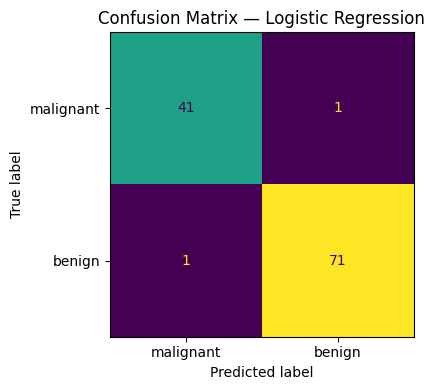

In [19]:
y_pred = model.predict(X_test_s)

print(classification_report(y_test, y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=data.target_names,
    ax=ax, colorbar=False
)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()

## Pipelines — no leakage, one object

A `Pipeline` chains transformers + estimator into a single object.

When you call `pipe.fit(X_train, y_train)`, sklearn automatically:
1. Calls `scaler.fit_transform(X_train)` → scaled features
2. Calls `clf.fit(scaled_features, y_train)` → trained model

`pipe.predict(X_test)` applies the same scaler before predicting.  
This makes leakage **impossible** and gives you a single object to save and tune

In [21]:
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('clf',   LogisticRegression(max_iter=10_000, random_state=42)),
])

pipe.fit(X_train, y_train)
print(f'Pipeline test accuracy: {pipe.score(X_test, y_test):.3f}')

# Works as a single unit for prediction too
print(f'First prediction: {data.target_names[pipe.predict(X_test[:1])[0]]}')

Pipeline test accuracy: 0.982
First prediction: malignant


## Cross-validation

With a single train/test split the score estimate depends on which samples ended up in test.  
**k-fold cross-validation** averages over `k` different splits for a more reliable estimate

In [22]:
scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'5-fold CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}')
print(f'Per fold          : {scores.round(3)}')

5-fold CV accuracy: 0.981 ± 0.007
Per fold          : [0.982 0.982 0.974 0.974 0.991]


## Hyperparameter tuning — GridSearchCV

Name pipeline parameters with the pattern `stepname__paramname`.  
`GridSearchCV` tries every combination and picks the best via cross-validation